# Лабораторная работа 3. Ассоциативные правила

Датасет: Online Retail (UCI).

Цель: реализовать Apriori и FP-Growth, сравнить время работы, сделать рекомендации к корзине.

## 1. Загрузка и подготовка данных

In [1]:
import time
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)

Загружаем сырые данные.

In [2]:
df = pd.read_excel('Online Retail.xlsx')
print('Размер исходных данных:', df.shape)
df.head()

Размер исходных данных: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Чистка: убираем отмены, пропуски, возвраты. Названия приводим к одному виду.

In [3]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df.dropna(subset=['Description'])
df = df[~df['InvoiceNo'].str.startswith('C')]
df = df[df['Quantity'] > 0]
df['Description'] = df['Description'].str.strip().str.upper()

print('После чистки:', df.shape)
print('Уникальных чеков:', df['InvoiceNo'].nunique())
print('Уникальных товаров:', df['Description'].nunique())

После чистки: (530693, 8)
Уникальных чеков: 20136
Уникальных товаров: 4060


Берём только Францию и собираем транзакции — список товаров на каждый чек.

In [4]:
df_fr = df[df['Country'] == 'France'].copy()

transactions = (
    df_fr.groupby('InvoiceNo')['Description']
    .apply(lambda s: sorted(set(s)))
    .tolist()
)

print('Транзакций:', len(transactions))
print('Средний размер чека:', round(np.mean([len(t) for t in transactions]), 1))
print('Максимум товаров в чеке:', max(len(t) for t in transactions))
print()
print('Пример транзакции:')
for item in transactions[0][:8]:
    print(' -', item)

Транзакций: 392
Средний размер чека: 21.4
Максимум товаров в чеке: 259

Пример транзакции:
 - ALARM CLOCK BAKELIKE GREEN
 - ALARM CLOCK BAKELIKE PINK
 - ALARM CLOCK BAKELIKE RED
 - CHARLOTTE BAG DOLLY GIRL DESIGN
 - CIRCUS PARADE LUNCH BOX
 - INFLATABLE POLITICAL GLOBE
 - LUNCH BOX I LOVE LONDON
 - MINI JIGSAW CIRCUS PARADE


Распределение размеров корзины.

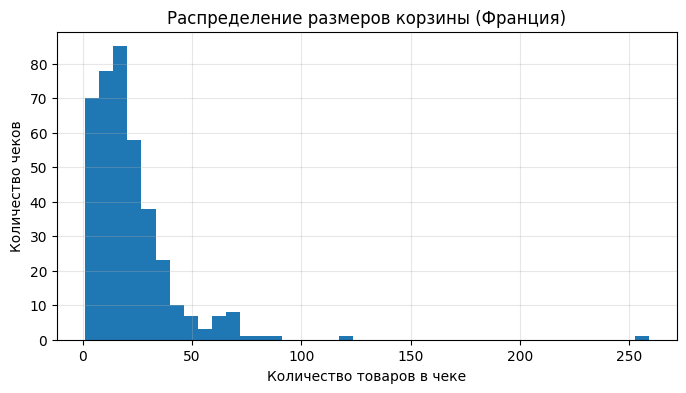

In [5]:
sizes = [len(t) for t in transactions]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=40)
plt.xlabel('Количество товаров в чеке')
plt.ylabel('Количество чеков')
plt.title('Распределение размеров корзины (Франция)')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Параметры поиска правил

Задаём пороги поддержки и уверенности.

In [6]:
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.5

n_transactions = len(transactions)
min_count = int(np.ceil(MIN_SUPPORT * n_transactions))
print(f'Транзакций: {n_transactions}')
print(f'min_support = {MIN_SUPPORT} -> минимум {min_count} вхождений')
print(f'min_confidence = {MIN_CONFIDENCE}')

Транзакций: 392
min_support = 0.03 -> минимум 12 вхождений
min_confidence = 0.5


## 3. Алгоритм Apriori

Вспомогательные функции: частые одиночные товары, генерация кандидатов, обрезка по антимонотонности, подсчёт поддержки.

In [7]:
def get_frequent_1_itemsets(transactions, min_count):
    counts = defaultdict(int)
    for t in transactions:
        for item in t:
            counts[item] += 1
    return {frozenset([item]): c for item, c in counts.items() if c >= min_count}


def generate_candidates(prev_level_sets, k):
    sorted_sets = [tuple(sorted(s)) for s in prev_level_sets]
    candidates = set()
    for i in range(len(sorted_sets)):
        for j in range(i + 1, len(sorted_sets)):
            a, b = sorted_sets[i], sorted_sets[j]
            if a[:-1] == b[:-1] and a[-1] != b[-1]:
                cand = frozenset(a) | frozenset(b)
                if len(cand) == k:
                    candidates.add(cand)
    return candidates


def prune_candidates(candidates, prev_level_sets):
    prev_set = set(prev_level_sets)
    pruned = set()
    for cand in candidates:
        ok = True
        for sub in combinations(cand, len(cand) - 1):
            if frozenset(sub) not in prev_set:
                ok = False
                break
        if ok:
            pruned.add(cand)
    return pruned


def count_supports(transactions, candidates):
    counts = defaultdict(int)
    tx_sets = [frozenset(t) for t in transactions]
    for tx in tx_sets:
        for cand in candidates:
            if cand.issubset(tx):
                counts[cand] += 1
    return counts


def apriori(transactions, min_support):
    n = len(transactions)
    min_count = int(np.ceil(min_support * n))

    L = get_frequent_1_itemsets(transactions, min_count)
    all_frequent = dict(L)
    levels = {1: dict(L)}

    k = 2
    while L:
        candidates = generate_candidates(list(L.keys()), k)
        candidates = prune_candidates(candidates, list(L.keys()))
        if not candidates:
            break
        counts = count_supports(transactions, candidates)
        L = {s: c for s, c in counts.items() if c >= min_count}
        if L:
            levels[k] = dict(L)
            all_frequent.update(L)
        k += 1

    supports = {s: c / n for s, c in all_frequent.items()}
    return supports, levels

Запуск Apriori и замер времени.

In [8]:
t0 = time.perf_counter()
ap_supports, ap_levels = apriori(transactions, MIN_SUPPORT)
t_apriori = time.perf_counter() - t0

print(f'Apriori: время = {t_apriori:.2f} сек')
print(f'Всего частых наборов: {len(ap_supports)}')
for k, level in ap_levels.items():
    print(f'  размер {k}: {len(level)} наборов')

Apriori: время = 0.37 сек
Всего частых наборов: 787
  размер 1: 171 наборов
  размер 2: 353 наборов
  размер 3: 207 наборов
  размер 4: 48 наборов
  размер 5: 8 наборов


## 4. Алгоритм FP-Growth

Узел FP-дерева.

In [9]:
class FPNode:
    def __init__(self, item, parent):
        self.item = item
        self.count = 0
        self.parent = parent
        self.children = {}
        self.next = None

    def increment(self, by=1):
        self.count += by

Построение FP-дерева и вставка пути.

In [10]:
def build_fp_tree(transactions, min_count):
    counts = defaultdict(int)
    for t in transactions:
        for item in t:
            counts[item] += 1
    counts = {item: c for item, c in counts.items() if c >= min_count}
    if not counts:
        return None, None, counts

    root = FPNode(None, None)
    header = {item: None for item in counts}

    for t in transactions:
        items = [it for it in t if it in counts]
        if not items:
            continue
        items.sort(key=lambda it: (-counts[it], it))
        insert_path(root, items, header, weight=1)

    return root, header, counts


def insert_path(node, items, header, weight):
    if not items:
        return
    head = items[0]
    if head in node.children:
        child = node.children[head]
    else:
        child = FPNode(head, node)
        node.children[head] = child
        if header[head] is None:
            header[head] = child
        else:
            cur = header[head]
            while cur.next is not None:
                cur = cur.next
            cur.next = child
    child.increment(weight)
    insert_path(child, items[1:], header, weight)

Сбор префиксных путей и рекурсивная добыча частых наборов.

In [11]:
def collect_prefix_paths(item, header):
    paths = []
    node = header[item]
    while node is not None:
        path = []
        cur = node.parent
        while cur is not None and cur.item is not None:
            path.append(cur.item)
            cur = cur.parent
        if path:
            path.reverse()
            paths.append((path, node.count))
        node = node.next
    return paths


def mine_fp_tree(header, item_counts, min_count, prefix, result):
    items_sorted = sorted(item_counts.items(), key=lambda kv: kv[1])
    for item, count in items_sorted:
        new_set = prefix | {item}
        result[frozenset(new_set)] = count

        paths = collect_prefix_paths(item, header)
        cond_counts = defaultdict(int)
        for path, cnt in paths:
            for it in path:
                cond_counts[it] += cnt
        cond_counts = {it: c for it, c in cond_counts.items() if c >= min_count}
        if not cond_counts:
            continue

        cond_root = FPNode(None, None)
        cond_header = {it: None for it in cond_counts}
        for path, cnt in paths:
            items = [it for it in path if it in cond_counts]
            items.sort(key=lambda it: (-cond_counts[it], it))
            insert_path(cond_root, items, cond_header, weight=cnt)

        mine_fp_tree(cond_header, cond_counts, min_count, new_set, result)


def fp_growth(transactions, min_support):
    n = len(transactions)
    min_count = int(np.ceil(min_support * n))

    root, header, counts = build_fp_tree(transactions, min_count)
    result = {}
    if root is None:
        return {}
    mine_fp_tree(header, counts, min_count, set(), result)

    supports = {s: c / n for s, c in result.items()}
    return supports

Запуск FP-Growth и замер времени.

In [12]:
t0 = time.perf_counter()
fp_supports = fp_growth(transactions, MIN_SUPPORT)
t_fpgrowth = time.perf_counter() - t0

print(f'FP-Growth: время = {t_fpgrowth:.2f} сек')
print(f'Всего частых наборов: {len(fp_supports)}')
by_size = defaultdict(int)
for s in fp_supports:
    by_size[len(s)] += 1
for k in sorted(by_size):
    print(f'  размер {k}: {by_size[k]} наборов')

FP-Growth: время = 0.01 сек
Всего частых наборов: 787
  размер 1: 171 наборов
  размер 2: 353 наборов
  размер 3: 207 наборов
  размер 4: 48 наборов
  размер 5: 8 наборов


## 5. Сравнение Apriori и FP-Growth

Проверка, что оба алгоритма нашли одни и те же наборы.

In [13]:
ap_keys = set(ap_supports.keys())
fp_keys = set(fp_supports.keys())
print('Только в Apriori:', len(ap_keys - fp_keys))
print('Только в FP-Growth:', len(fp_keys - ap_keys))
print('В обоих:', len(ap_keys & fp_keys))

diffs = [abs(ap_supports[k] - fp_supports[k]) for k in (ap_keys & fp_keys)]
print(f'Максимальная разница в support: {max(diffs):.2e}' if diffs else 'нет общих')

Только в Apriori: 0
Только в FP-Growth: 0
В обоих: 787
Максимальная разница в support: 0.00e+00


Сводка по времени.

In [14]:
print(f'{"Алгоритм":<12} {"Время, сек":>12} {"Наборов":>10}')
print('-' * 36)
print(f'{"Apriori":<12} {t_apriori:>12.2f} {len(ap_supports):>10}')
print(f'{"FP-Growth":<12} {t_fpgrowth:>12.2f} {len(fp_supports):>10}')
print(f'\nFP-Growth быстрее в {t_apriori / t_fpgrowth:.1f} раз')

Алгоритм       Время, сек    Наборов
------------------------------------
Apriori              0.37        787
FP-Growth            0.01        787

FP-Growth быстрее в 26.7 раз


Время работы на разных порогах поддержки.

In [15]:
supports_grid = [0.10, 0.07, 0.05, 0.04, 0.03, 0.025, 0.02]
rows = []
for s in supports_grid:
    t0 = time.perf_counter()
    ap_s, _ = apriori(transactions, s)
    t_ap = time.perf_counter() - t0

    t0 = time.perf_counter()
    fp_s = fp_growth(transactions, s)
    t_fp = time.perf_counter() - t0

    rows.append({'min_support': s, 'apriori_sec': t_ap, 'fpgrowth_sec': t_fp,
                 'sets_apriori': len(ap_s), 'sets_fp': len(fp_s)})
    print(f'support={s:.3f}: apriori={t_ap:.2f}s ({len(ap_s)} наборов), fp-growth={t_fp:.2f}s ({len(fp_s)} наборов)')

bench = pd.DataFrame(rows)
bench

support=0.100: apriori=0.01s (45 наборов), fp-growth=0.00s (45 наборов)
support=0.070: apriori=0.02s (90 наборов), fp-growth=0.00s (90 наборов)
support=0.050: apriori=0.07s (195 наборов), fp-growth=0.01s (195 наборов)


support=0.040: apriori=0.17s (333 наборов), fp-growth=0.01s (333 наборов)


support=0.030: apriori=0.37s (787 наборов), fp-growth=0.01s (787 наборов)


support=0.025: apriori=0.62s (1306 наборов), fp-growth=0.02s (1306 наборов)


support=0.020: apriori=1.32s (2509 наборов), fp-growth=0.03s (2509 наборов)


,min_support,apriori_sec,fpgrowth_sec,sets_apriori,sets_fp
0,0.100,0.006586,0.002356,45,45
1,0.070,0.020262,0.003689,90,90
2,0.050,0.072603,0.006115,195,195
3,0.040,0.165706,0.008970,333,333
4,0.030,0.371994,0.013168,787,787
5,0.025,0.618870,0.017310,1306,1306
6,0.020,1.319866,0.026197,2509,2509


График времени работы (лог-шкала).

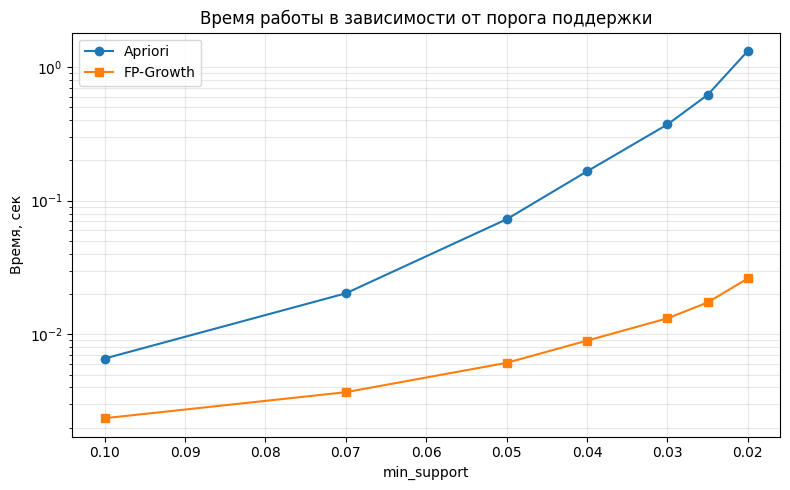

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bench['min_support'], bench['apriori_sec'], marker='o', label='Apriori')
ax.plot(bench['min_support'], bench['fpgrowth_sec'], marker='s', label='FP-Growth')
ax.set_xlabel('min_support')
ax.set_ylabel('Время, сек')
ax.set_title('Время работы в зависимости от порога поддержки')
ax.invert_xaxis()
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Генерация правил

Из частых наборов строим правила X -> Y с confidence и lift.

In [17]:
def generate_rules(supports, min_confidence):
    rules = []
    for itemset, sup in supports.items():
        if len(itemset) < 2:
            continue
        items = list(itemset)
        for r in range(1, len(items)):
            for combo in combinations(items, r):
                X = frozenset(combo)
                Y = itemset - X
                sup_X = supports.get(X)
                sup_Y = supports.get(Y)
                if sup_X is None or sup_Y is None:
                    continue
                conf = sup / sup_X
                if conf >= min_confidence:
                    lift = conf / sup_Y
                    rules.append({
                        'antecedent': X,
                        'consequent': Y,
                        'support': sup,
                        'confidence': conf,
                        'lift': lift,
                    })
    return rules

Сборка таблицы правил, сортировка по lift.

In [18]:
rules = generate_rules(fp_supports, MIN_CONFIDENCE)
print(f'Всего правил с confidence >= {MIN_CONFIDENCE}: {len(rules)}')

rules_df = pd.DataFrame([
    {
        'antecedent': ', '.join(sorted(r['antecedent'])),
        'consequent': ', '.join(sorted(r['consequent'])),
        'support': r['support'],
        'confidence': r['confidence'],
        'lift': r['lift'],
    }
    for r in rules
])
rules_df = rules_df.sort_values(['lift', 'confidence'], ascending=False).reset_index(drop=True)
rules_df.head(15)

Всего правил с confidence >= 0.5: 1293


,antecedent,consequent,support,confidence,lift
0,"PACK OF 6 SKULL PAPER PLATES, SET/20 RED RETROSPOT PAPER...","PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER P...",0.030612,0.923077,25.846154
1,"PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER P...","PACK OF 6 SKULL PAPER PLATES, SET/20 RED RETROSPOT PAPER...",0.030612,0.857143,25.846154
2,"PACK OF 20 SKULL PAPER NAPKINS, PACK OF 6 SKULL PAPER CU...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS",0.030612,1.000000,24.500000
3,"PACK OF 20 SKULL PAPER NAPKINS, PACK OF 6 SKULL PAPER CU...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER PLATES",0.030612,1.000000,24.500000
4,"PACK OF 20 SKULL PAPER NAPKINS, SET/20 RED RETROSPOT PAP...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS",0.030612,1.000000,24.500000
5,"PACK OF 20 SKULL PAPER NAPKINS, SET/20 RED RETROSPOT PAP...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER PLATES",0.030612,1.000000,24.500000
6,"PACK OF 20 SKULL PAPER NAPKINS, POSTAGE, SET/6 RED SPOTT...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS",0.033163,1.000000,24.500000
7,"PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER P...","PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS",0.035714,1.000000,24.500000
8,"PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS","PACK OF 20 SKULL PAPER NAPKINS, POSTAGE, SET/6 RED SPOTT...",0.033163,0.812500,24.500000
9,"PACK OF 6 SKULL PAPER PLATES, SET/6 RED SPOTTY PAPER CUPS","PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER P...",0.035714,0.875000,24.500000


Графики распределения правил.

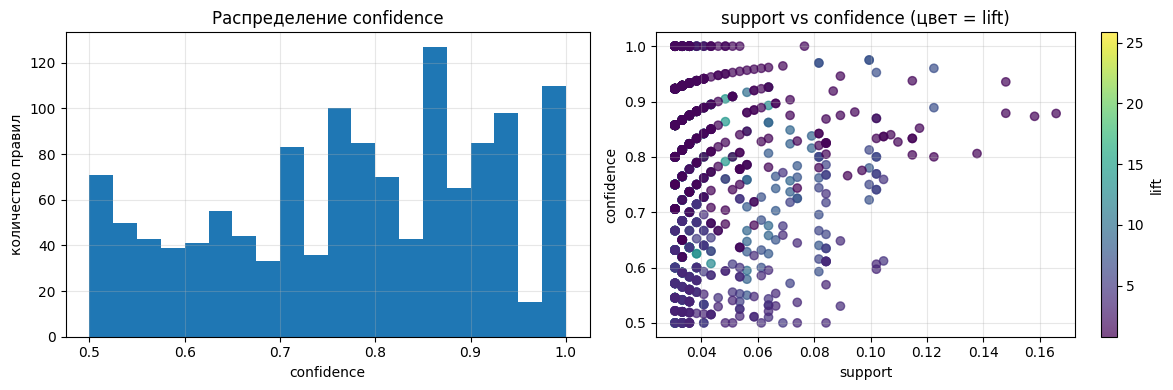

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rules_df['confidence'], bins=20)
axes[0].set_xlabel('confidence')
axes[0].set_ylabel('количество правил')
axes[0].set_title('Распределение confidence')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(rules_df['support'], rules_df['confidence'], c=rules_df['lift'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('support')
axes[1].set_ylabel('confidence')
axes[1].set_title('support vs confidence (цвет = lift)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='lift')
plt.tight_layout()
plt.show()

## 7. Рекомендации к корзине

Функция: на вход корзина, на выход топ рекомендаций по lift.

In [20]:
def recommend(basket, rules, top_n=5):
    basket_set = frozenset(item.strip().upper() for item in basket)

    best_per_item = {}
    for r in rules:
        if not r['antecedent'].issubset(basket_set):
            continue
        new_items = r['consequent'] - basket_set
        if not new_items:
            continue
        for item in new_items:
            cur = best_per_item.get(item)
            score = (r['lift'], r['confidence'])
            if cur is None or score > (cur['lift'], cur['confidence']):
                best_per_item[item] = {
                    'antecedent': r['antecedent'],
                    'support': r['support'],
                    'confidence': r['confidence'],
                    'lift': r['lift'],
                }

    items_sorted = sorted(best_per_item.items(),
                          key=lambda kv: (kv[1]['lift'], kv[1]['confidence']),
                          reverse=True)
    return items_sorted[:top_n]


def show_recommendations(basket, recs):
    print('Корзина:')
    for item in basket:
        print(' -', item)
    if not recs:
        print('\nРекомендаций нет: ни одно правило не срабатывает.')
        return
    print('\nРекомендации:')
    for item, info in recs:
        ante = ', '.join(sorted(info['antecedent']))
        print(f'  + {item}')
        print(f'      потому что вы взяли: {ante}')
        print(f'      confidence={info["confidence"]:.2f}, lift={info["lift"]:.2f}, support={info["support"]:.3f}')

Проверка 1: корзины из левых частей самых сильных правил.

In [21]:
example_baskets = []
seen = set()
for r in sorted(rules, key=lambda x: -x['lift']):
    key = tuple(sorted(r['antecedent']))
    if key in seen:
        continue
    seen.add(key)
    example_baskets.append(list(r['antecedent']))
    if len(example_baskets) == 3:
        break

for b in example_baskets:
    print('---')
    show_recommendations(b, recommend(b, rules))

---
Корзина:
 - SET/6 RED SPOTTY PAPER PLATES
 - PACK OF 20 SKULL PAPER NAPKINS

Рекомендации:
  + PACK OF 6 SKULL PAPER PLATES
      потому что вы взяли: PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER PLATES
      confidence=0.86, lift=25.85, support=0.031
  + SET/6 RED SPOTTY PAPER CUPS
      потому что вы взяли: PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER PLATES
      confidence=0.86, lift=25.85, support=0.031
  + SET/20 RED RETROSPOT PAPER NAPKINS
      потому что вы взяли: PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER PLATES
      confidence=0.86, lift=25.85, support=0.031
  + POSTAGE
      потому что вы взяли: PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER PLATES
      confidence=0.93, lift=24.27, support=0.033
  + PACK OF 6 SKULL PAPER CUPS
      потому что вы взяли: PACK OF 20 SKULL PAPER NAPKINS, SET/6 RED SPOTTY PAPER PLATES
      confidence=0.86, lift=24.00, support=0.031
---
Корзина:
 - PACK OF 6 SKULL PAPER PLATES
 - SET/6 RED SPOTTY PAP

Проверка 2: корзина с товаром не из данных.

In [22]:
print('---')
show_recommendations(['SOMETHING NOT IN DATA'], recommend(['SOMETHING NOT IN DATA'], rules))

---
Корзина:
 - SOMETHING NOT IN DATA

Рекомендаций нет: ни одно правило не срабатывает.


Проверка 3: половина случайного реального чека.

In [23]:
rng = np.random.default_rng(0)
for _ in range(3):
    idx = rng.integers(len(transactions))
    basket = transactions[idx]
    if len(basket) < 4:
        continue
    half = basket[: len(basket) // 2]
    print('---')
    show_recommendations(half, recommend(half, rules))

---
Корзина:
 - CHARLOTTE BAG APPLES DESIGN
 - CHARLOTTE BAG DOLLY GIRL DESIGN
 - PENS ASSORTED FUNNY FACE
 - PENS ASSORTED SPACEBALL
 - PLASTERS IN TIN CIRCUS PARADE
 - PLASTERS IN TIN SPACEBOY
 - PLASTERS IN TIN WOODLAND ANIMALS

Рекомендации:
  + POSTAGE
      потому что вы взяли: CHARLOTTE BAG DOLLY GIRL DESIGN, PLASTERS IN TIN WOODLAND ANIMALS
      confidence=0.86, lift=7.47, support=0.031
  + RED RETROSPOT CHARLOTTE BAG
      потому что вы взяли: CHARLOTTE BAG APPLES DESIGN
      confidence=0.56, lift=5.73, support=0.038
---
Корзина:
 - CALENDAR PAPER CUT DESIGN
 - DRAWER KNOB CERAMIC IVORY
 - GINGERBREAD MAN COOKIE CUTTER
 - HEART FILIGREE DOVE LARGE
 - HOME SWEET HOME MUG
 - METAL DECORATION NAUGHTY CHILDREN

Рекомендации:
  + POSTAGE
      потому что вы взяли: GINGERBREAD MAN COOKIE CUTTER
      confidence=1.00, lift=1.31, support=0.043
